# EK Draconis

One of the most studied stars concerning CMEs is EK Draconis, which counted 2 CMEs associated to 11 flares (Nameketa 2025). We calculated the expected percentage of captured CME per flare our model predict for the star EK Draconis.

Here are the basic properties of the star:

In [1]:
inclination = 61   # degrees
period = 2.7        # days
stellar_radius = 0.90   # R_sun

n_flares_observed = 11
n_cmes_observed = 2
observed_ratio = n_cmes_observed / n_flares_observed
print(f"observed capture ratio: {n_cmes_observed}/{n_flares_observed} = {observed_ratio*100:.1f}%")


observed capture ratio: 2/11 = 18.2%


## Model set-up

Since EK Draconis is described as having solar-like flare activity, we reuse the same active-region
distribution $\rho(\alpha)$ (Rice-distribution fit, see `experimental_flare_distribution.ipynb`) and the
same near-radial CME ejection-angle distribution $\rho^{CME}(\theta')$ used as the main model in
`CME_distribution.ipynb`. The only star-specific ingredient is the orientation angle $\tau$, which we
take equal to the stellar inclination ($\tau = 61$°: $\tau=0$ is pole-on, $\tau=\pi/2$ is
equator-on, exactly like the usual definition of stellar inclination).

In [2]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad, cumulative_trapezoid
from scipy.stats import norm
from scipy.interpolate import make_interp_spline
from pathlib import Path


In [3]:
# general distribution of active regions per unit area (Sun-like, Rice-distribution fit)
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)

def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err)


# CME ejection-angle distribution, near-radial (same default as CME_distribution.ipynb)
def rho_CME(theta2, loc=0, scale=0.2):
    f = lambda t2: norm.pdf(t2, loc, scale) * np.sin(t2) * 2 * np.pi
    N = quad(f, 0, np.pi / 2)[0]
    return norm.pdf(theta2, loc, scale) / N


tau = inclination / 180 * np.pi


## Distribution of CMEs in viewing angle $\beta$ for EK Draconis

We reuse the same reduction of the geometric integral used throughout the other notebooks
(see `CME_distribution.ipynb` and `CME_dist_multiple_output_angles.ipynb`), evaluated with the fast
vectorised Monte Carlo estimator at the single orientation $\tau=61$°, and cache the result to
`calculations/`.

In [4]:
from scipy.stats import qmc

def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))


def mc_rho_betas(betas, tau, m=23, seed=0):
    """Vectorised, scrambled-Sobol' Monte Carlo estimate of rho_beta(beta) for every beta at once.
    Sobol' quasi-random sampling (instead of plain pseudo-random draws) reduces the spurious
    correlated noise that shows up as "wobble" across the beta grid -- same fix as in
    CME_distribution.ipynb / CME_dist_multiple_output_angles.ipynb. m=23 means 2**23 (~8.4M) samples.
    """
    sampler = qmc.Sobol(d=3, scramble=True, seed=seed)
    u = sampler.random_base2(m=m)
    theta = (u[:, 0] * np.pi)[:, None]
    phi = (u[:, 1] * 2 * np.pi)[:, None]
    theta2 = (u[:, 2] * np.pi / 2)[:, None]
    betas = np.asarray(betas)[None, :]

    alpha = get_alpha(tau, theta, phi)

    denom = np.sin(theta) * np.sin(theta2)
    cosphi2 = (np.cos(betas) - np.cos(theta) * np.cos(theta2)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)

    mask = (betas >= theta - theta2) & (betas <= theta + theta2) & (sinphi2 > 1e-6)
    safe_sinphi2 = np.where(mask, sinphi2, 1.0)
    # sin(phi') in the denominator; sin(theta), sin(theta2) cancel against the measure.
    # See CME_distribution.ipynb for the derivation.
    integrand = np.where(mask, rho(alpha) * rho_CME(theta2) / safe_sinphi2, 0.0)

    volume = np.pi * (2 * np.pi) * (np.pi / 2)
    mean_val = integrand.mean(axis=0) * volume
    return mean_val * np.abs(np.sin(betas.ravel())) / 2


def get_or_create_data(name, compute_fn):
    filename = f'calculations/{name}.npy'
    file_path = Path(filename)

    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")
        data = compute_fn()
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")

    return data


betas = np.linspace(0, np.pi / 2, 60)
dens = get_or_create_data("EK_Draconis_betadist", lambda: mc_rho_betas(betas, tau))

File 'calculations/EK_Draconis_betadist.npy' found.


## Flare, CME and cumulative-detection distributions

We reuse the three-panel layout from `Figures/Figures_CME_distribution_AND_bands.ipynb`
(`plot_flare_cme_pdf_cdf_3x1`): the flare distribution in $\mu$, the CME distribution in $\beta$
(normalised probability density, with the line-of-sight speed $v_{\rm los}=v_0\cos\beta$ shown on
the secondary top axis for a fiducial total CME speed $v_0=600$ km/s), and its cumulative distribution
in $\beta$ (as a percentage). The dashed red curve is the isotropic reference (no geometric
suppression). The shaded band marks $v_{\rm los} > 400$ km/s — the line-of-sight speed above which we
take a CME to be Doppler-detectable (see below).

C:\Users\mdewilde\AppData\Local\Temp\ipykernel_10492\3704250808.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_10492\3704250808.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d, betas)


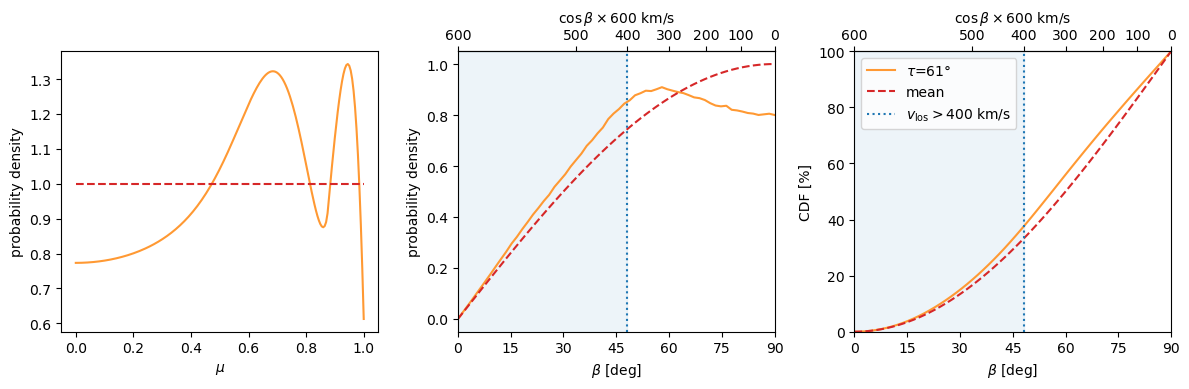

In [5]:
v0 = 600          # km/s, fiducial total CME speed (same convention as CME_distribution.ipynb)
v_threshold = 400  # km/s, the adopted Doppler-detection threshold

def speed2beta(v, v0=v0):
    return np.arccos(np.clip(v / v0, -1, 1))

def beta2speed(beta, v0=v0):
    return np.cos(beta) * v0


def rho_mu(mu, tau):
    theta = np.arccos(mu)
    I = lambda phi: rho(get_alpha(tau, theta, phi))
    return 2 * quad(I, 0, 2 * np.pi)[0]


def plot_flare_cme_pdf_cdf_3x1(taus, betas, dens_list, beta2speed=None, speed2beta=None,
                                n_mu=200, mu_min=0.0, mu_max=1.0, name="dist", loc=0,
                                cmap_name="gist_heat_r", v_threshold=None):
    taus = np.asarray(taus, dtype=float)
    mu = np.linspace(mu_min, mu_max, int(n_mu))

    betas = np.asarray(betas, dtype=float)
    dens_list = np.asarray(dens_list, dtype=float)

    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.2, 0.9, len(taus)))

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

    beta_thr = speed2beta(v_threshold) if (v_threshold is not None and speed2beta is not None) else None

    # (1) flare PDF in mu
    ax = axs[0]
    for c, tau_ in zip(colors, taus):
        y = np.array([rho_mu(m, tau_) for m in mu], dtype=float)
        ax.plot(mu, y / np.average(y), color=c, label=fr'$\tau$={int(round(tau_*180/np.pi))}°')
    ax.plot(mu, np.ones_like(mu), "--", color="tab:red", label="mean")
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("probability density")
    if loc == 0:
        ax.legend()

    # (2) CME PDF in beta, normalised
    ax = axs[1]
    for c, d, tau_ in zip(colors, dens_list, taus):
        area = np.trapz(d, betas)
        d_pdf = d / area if area != 0 else d
        ax.plot(betas, d_pdf, color=c, label=fr'$\tau$={int(round(tau_*180/np.pi))}°')
    ax.plot(betas, np.sin(betas), "--", color="tab:red", label="mean")
    ax.set_xlabel(r"$\beta$ [deg]")
    ax.set_ylabel("probability density")
    if beta_thr is not None:
        ax.axvspan(0, beta_thr, color="tab:blue", alpha=0.08)
        ax.axvline(beta_thr, color="tab:blue", linestyle=":", lw=1.5, label=fr"$v_{{\rm los}}>{v_threshold}$ km/s")
    if (beta2speed is not None) and (speed2beta is not None):
        secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
        secax.set_xlabel(r'$\cos \beta \times 600$ km/s')
    if betas.min() >= 0 and betas.max() <= np.pi/2 + 1e-6:
        ax.set_xticks(np.linspace(0, np.pi/2, 7))
        ax.set_xticklabels(range(0, 91, 15))
        ax.set_xlim(0, np.pi/2)
    if loc == 1:
        ax.legend()

    # (3) CME CDF in beta, percent
    ax = axs[2]
    for c, d, tau_ in zip(colors, dens_list, taus):
        area = np.trapz(d, betas)
        d_pdf = d / area if area != 0 else d
        cdf = np.cumsum((d_pdf[:-1] + d_pdf[1:]) * 0.5 * np.diff(betas))
        cdf = np.concatenate(([0.0], cdf))
        ax.plot(betas, cdf * 100, color=c, label=fr'$\tau$={int(round(tau_*180/np.pi))}°')
    mean_cdf = (1.0 - np.cos(betas)) * 100
    ax.plot(betas, mean_cdf, "--", color="tab:red", label="mean")
    ax.set_xlabel(r"$\beta$ [deg]")
    ax.set_ylabel("CDF [%]")
    ax.set_ylim(0, 100)
    if beta_thr is not None:
        ax.axvspan(0, beta_thr, color="tab:blue", alpha=0.08)
        ax.axvline(beta_thr, color="tab:blue", linestyle=":", lw=1.5, label=fr"$v_{{\rm los}}>{v_threshold}$ km/s")
    if (beta2speed is not None) and (speed2beta is not None):
        secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
        secax.set_xlabel(r'$\cos \beta \times 600$ km/s')
    if betas.min() >= 0 and betas.max() <= np.pi/2 + 1e-6:
        ax.set_xticks(np.linspace(0, np.pi/2, 7))
        ax.set_xticklabels(range(0, 91, 15))
        ax.set_xlim(0, np.pi/2)
    if loc == 2:
        ax.legend()

    plt.tight_layout()
    Path("Figures").mkdir(exist_ok=True)
    plt.savefig(f"Figures/{name}.pdf")
    return fig, axs


fig, axs = plot_flare_cme_pdf_cdf_3x1(
    taus=[tau],
    betas=betas,
    dens_list=[dens],
    beta2speed=beta2speed,
    speed2beta=speed2beta,
    name="EK_Draconis_dist",
    loc=2,
    cmap_name="gist_heat_r",
    v_threshold=v_threshold,
)
plt.show()

## Predicted captured-CME fraction at the adopted detection threshold

We take a CME to be Doppler-detectable from the moment its line-of-sight speed exceeds
$v_{\rm los} = 400$ km/s, i.e. $\beta < \beta_{\max} = \arccos(400/v_0)$. The model-predicted
captured-CME fraction (our proxy for "expected percentage of captured CME per flare") is then

$$
P(\text{captured}) = \frac{\int_0^{\beta_{\max}} \rho_\beta(\beta)\, d\beta}{\int_0^{\pi/2} \rho_\beta(\beta)\, d\beta}.
$$

In [6]:
cdf = cumulative_trapezoid(dens, betas, initial=0)
total = cdf[-1]
beta_threshold = speed2beta(v_threshold)
predicted_pct = np.interp(beta_threshold, betas, cdf) / total * 100

print(f"Detection threshold: v_los > {v_threshold} km/s  (beta < {np.degrees(beta_threshold):.1f} deg)")
print(f"Model-predicted captured-CME fraction (geometry only): {predicted_pct:.1f}%")
print(f"Observed captured-CME fraction: {observed_ratio*100:.1f}%  ({n_cmes_observed}/{n_flares_observed})")
print(f"Model is {predicted_pct - observed_ratio*100:.1f} percentage points higher than observed.")


Detection threshold: v_los > 400 km/s  (beta < 48.2 deg)
Model-predicted captured-CME fraction (geometry only): 37.7%
Observed captured-CME fraction: 18.2%  (2/11)
Model is 19.5 percentage points higher than observed.


For context, the plot below shows how the predicted captured-CME fraction depends on the assumed
detection threshold $v_{\min}$ across its full range, together with the isotropic (no geometric
suppression) reference and the observed ratio. The point at $v_{\min}=400$ km/s is the number quoted
above.

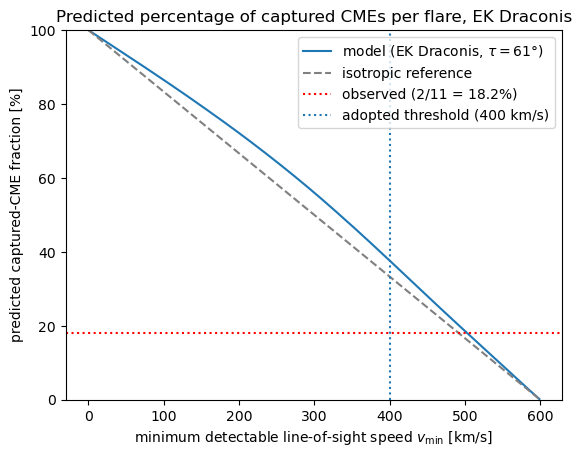

In [7]:
def capture_fraction(v_min):
    beta_max = speed2beta(v_min)
    return np.interp(beta_max, betas, cdf) / total


v_min_grid = np.linspace(0, v0 - 1, 400)
capture_pct = np.array([capture_fraction(v) for v in v_min_grid]) * 100

# isotropic / naive reference: same calculation but using sin(beta) instead of the model density
cdf_iso = cumulative_trapezoid(np.sin(betas), betas, initial=0)
total_iso = cdf_iso[-1]
capture_pct_iso = np.array([np.interp(speed2beta(v), betas, cdf_iso) / total_iso for v in v_min_grid]) * 100

plt.plot(v_min_grid, capture_pct, label="model (EK Draconis, $\\tau=61$°)")
plt.plot(v_min_grid, capture_pct_iso, "--", color='grey', label="isotropic reference")
plt.axhline(observed_ratio * 100, color='red', linestyle=':', label=f"observed ({n_cmes_observed}/{n_flares_observed} = {observed_ratio*100:.1f}%)")
plt.axvline(v_threshold, color='tab:blue', linestyle=':', label=f"adopted threshold ({v_threshold} km/s)")
plt.xlabel(r"minimum detectable line-of-sight speed $v_{\min}$ [km/s]")
plt.ylabel("predicted captured-CME fraction [%]")
plt.title("Predicted percentage of captured CMEs per flare, EK Draconis")
plt.legend()
plt.ylim(0, 100)
plt.show()


## Note: the above does not include rotation

This calculation uses the same non-rotating model as `CME_distribution.ipynb`: the only speed entering
$v_{\rm los}$ is the CME's own ejection speed $v_0\cos\beta$. It does **not** include the
star's-own-rotation correction in `CME_distribution_rotation.ipynb`, where the observed
Doppler velocity gets an extra contribution $\omega(\alpha) R \sin\tau\sin\phi\sin\theta$ from the
star's rotation itself.

For EK Draconis ($R=0.90\,R_\odot$, $P=2.7$ d, assuming a rigid rotator) the equatorial rotation speed is

$$v_{\rm rot} = \frac{2\pi R}{P} \approx 17\ \text{km/s},$$

only about 3% of the 400-600 km/s CME speeds involved here, so it is unlikely to change the
qualitative picture. We fold it in explicitly below rather than just arguing it away, so we have a
real number instead of an order-of-magnitude guess.

## Adding the rotation term


We reuse the physical set-up from `CME_distribution_rotation.ipynb`: the line-of-sight speed picks up an
extra contribution from the star's own rotation,

$$
d = v_0\left(\sin\theta\sin\theta'\cos\phi' + \cos\theta'\cos\theta\right) + \omega R \sin\tau\sin\phi\sin\theta.
$$

Reducing the $\phi'$ integral against the delta function the same way as for the non-rotating case
(same chain-rule argument as in `CME_distribution.ipynb`, since the extra rotation term doesn't depend
on $\phi'$ and so doesn't change the Jacobian) gives

$$
\rho_d(d) = \frac{1}{N}\int_{[0,\pi]\times[0,2\pi]\times[0,\pi/2]} d\theta\,d\phi\,d\theta'\;
\frac{\rho(\alpha(\theta,\phi))\,\rho^{CME}(\theta')}{\sin\phi'(\theta,\phi,\theta',d,\tau) + \epsilon},
\qquad
\cos\phi' = \frac{d - v_0\cos\theta\cos\theta' - \omega R\sin\tau\sin\phi\sin\theta}{v_0\sin\theta\sin\theta'}.
$$

For EK Draconis, $v_0=600$ km/s (the same fiducial CME speed used throughout) and $\tau=61$°, as before.
The rotation term uses the actual equatorial rotation speed computed earlier,
$\omega R = 2\pi R/P \approx 17$ km/s — not the illustrative $\omega R = v_0$ "fast rotator" limit used
in `CME_distribution_rotation.ipynb` itself, which is a toy case chosen to make the effect visible, not a
realistic ratio for this particular star.

We evaluate $\rho_d(d)$ with the same vectorised, scrambled-Sobol' Monte Carlo estimator used in
`CME_distribution.ipynb` (m=23, i.e. ~8.4M samples) rather than `nquad`, for the same reason: this
integrand also has an integrable singularity at the domain boundary.

omega*R = 16.87 km/s  (2.8% of v0=600 km/s)
File 'calculations/EK_Draconis_dop_rotation.npy' found.
File 'calculations/EK_Draconis_dop_norotation.npy' found.


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_10492\2583393931.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(dops, dens_rot / np.trapz(dens_rot, dops), color="tab:purple", label=fr"with rotation ($\omega R={omega_R:.0f}$ km/s)")
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_10492\2583393931.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(dops, dens_norot / np.trapz(dens_norot, dops), "--", color="tab:orange", label="without rotation")


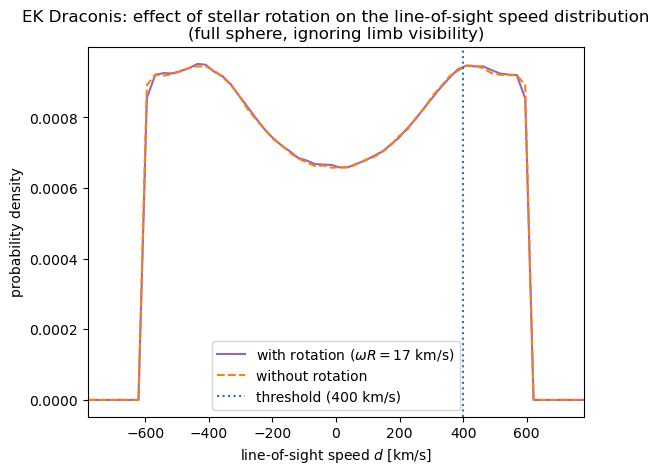

In [8]:
from scipy.stats import qmc

R_km = stellar_radius * 696_000       # km
P_s = period * 86400                  # s
omega_R = 2 * np.pi * R_km / P_s      # km/s, equatorial rotation speed
print(f"omega*R = {omega_R:.2f} km/s  ({omega_R/v0*100:.1f}% of v0={v0} km/s)")


def mc_rho_dops(dops, tau, v0, omega_R, theta_max=np.pi, m=23, seed=0):
    sampler = qmc.Sobol(d=3, scramble=True, seed=seed)
    u = sampler.random_base2(m=m)
    theta = (u[:, 0] * theta_max)[:, None]
    phi = (u[:, 1] * 2 * np.pi)[:, None]
    theta2 = (u[:, 2] * np.pi / 2)[:, None]
    dops_ = np.asarray(dops)[None, :]

    alpha = get_alpha(tau, theta, phi)
    denom = v0 * np.sin(theta) * np.sin(theta2)
    cosphi2 = (dops_ - v0 * np.cos(theta) * np.cos(theta2)
               - omega_R * np.sin(tau) * np.sin(phi) * np.sin(theta)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)

    # verified-correct form: sin(theta)*sin(theta2) cancelled against the measure (see markdown above).
    integrand = np.where(valid, rho(alpha) * rho_CME(theta2) / (sinphi2 + 1e-3), 0.0)
    volume = theta_max * (2 * np.pi) * (np.pi / 2)
    return integrand.mean(axis=0) * volume


dops = np.linspace(-1.3 * v0, 1.3 * v0, 60)
dens_rot = get_or_create_data("EK_Draconis_dop_rotation", lambda: mc_rho_dops(dops, tau, v0, omega_R))
# the omega_R=0 limit, computed with the exact same function/normalisation, so it's a like-for-like
# "without rotation" baseline (unlike the beta-restricted `dens`/`predicted_pct` computed earlier).
dens_norot = get_or_create_data("EK_Draconis_dop_norotation", lambda: mc_rho_dops(dops, tau, v0, 0.0))

plt.plot(dops, dens_rot / np.trapz(dens_rot, dops), color="tab:purple", label=fr"with rotation ($\omega R={omega_R:.0f}$ km/s)")
plt.plot(dops, dens_norot / np.trapz(dens_norot, dops), "--", color="tab:orange", label="without rotation")
plt.axvline(v_threshold, color="tab:blue", linestyle=":", label=f"threshold ({v_threshold} km/s)")
plt.xlabel(r"line-of-sight speed $d$ [km/s]")
plt.ylabel("probability density")
plt.title("EK Draconis: effect of stellar rotation on the line-of-sight speed distribution\n(full sphere, ignoring limb visibility)")
plt.legend()
plt.xlim(-1.3 * v0, 1.3 * v0)
plt.show()

## Seeing partially behind the limb

So far "visible" has meant $\theta \le \pi/2$ (the flare's own position $\theta$, measured from the
sub-observer point, is on the near side) — a flare exactly *at* the limb ($\theta=\pi/2$) is
marginally visible, anything further ($\theta>\pi/2$) is not. That's only true for a flare sitting
exactly on the stellar surface. Real flares stand at some height $h$ above the photosphere — taking
$h\approx0.01\,R_\star$ (solar-like) — so a flare slightly *behind* the geometric limb can still peek
out past the star's silhouette if it's tall enough.

For an observer effectively at infinity (parallel lines of sight), a feature at radius $R+h$ and
colatitude $\theta$ from the sub-observer point has an impact parameter (perpendicular distance from
the observer-star axis) of $(R+h)\sin\theta$. It is occulted by the star only if it's on the far side
*and* that impact parameter is smaller than $R$. So the visibility boundary is where

$$
(R+h)\sin\theta_{\max} = R \quad\Longrightarrow\quad \sin\theta_{\max} = \frac{R}{R+h},
$$

taking the root with $\theta_{\max}>\pi/2$ (the near-side root of the same equation is not the one we
want). Writing $\theta_{\max} = \pi/2 + \chi$, this is the same statement as
$\cos\chi = R/(R+h)$ — i.e. $\chi = \arccos\!\big(R/(R+h)\big) \approx \sqrt{2h/R}$ for $h\ll R$, the
extra angle we can see past the geometric limb.


chi = 8.07 deg behind the geometric limb is still visible (theta_max = 98.07 deg from the sub-observer point)
File 'calculations/EK_Draconis_dop_rotation_limb.npy' found.
File 'calculations/EK_Draconis_dop_norotation_limb.npy' found.


C:\Users\mdewilde\AppData\Local\Temp\ipykernel_10492\4171505398.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(dops, dens_rot_limb / np.trapz(dens_rot_limb, dops), color="tab:purple",
C:\Users\mdewilde\AppData\Local\Temp\ipykernel_10492\4171505398.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(dops, dens_norot_limb / np.trapz(dens_norot_limb, dops), "--", color="tab:orange",


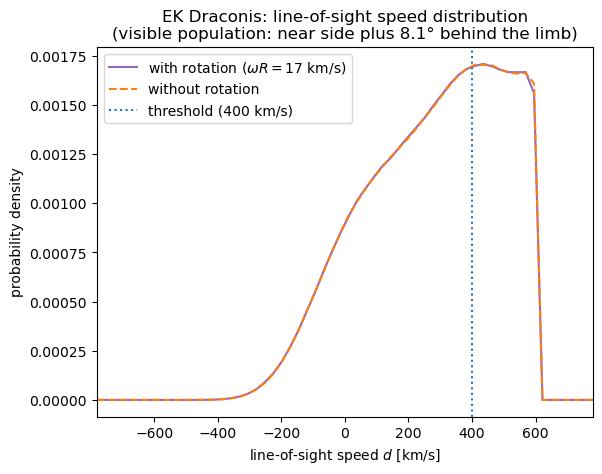

In [9]:
h_over_R = 0.01  # flare height, ~1% of the stellar radius ("solar-like" flare size)
chi = np.arccos(1.0 / (1.0 + h_over_R))
theta_max = np.pi / 2 + chi
print(f"chi = {np.degrees(chi):.2f} deg behind the geometric limb is still visible "
      f"(theta_max = {np.degrees(theta_max):.2f} deg from the sub-observer point)")

dens_rot_limb = get_or_create_data(
    "EK_Draconis_dop_rotation_limb", lambda: mc_rho_dops(dops, tau, v0, omega_R, theta_max=theta_max))
dens_norot_limb = get_or_create_data(
    "EK_Draconis_dop_norotation_limb", lambda: mc_rho_dops(dops, tau, v0, 0.0, theta_max=theta_max))

plt.plot(dops, dens_rot_limb / np.trapz(dens_rot_limb, dops), color="tab:purple",
         label=fr"with rotation ($\omega R={omega_R:.0f}$ km/s)")
plt.plot(dops, dens_norot_limb / np.trapz(dens_norot_limb, dops), "--", color="tab:orange",
         label="without rotation")
plt.axvline(v_threshold, color="tab:blue", linestyle=":", label=f"threshold ({v_threshold} km/s)")
plt.xlabel(r"line-of-sight speed $d$ [km/s]")
plt.ylabel("probability density")
plt.title("EK Draconis: line-of-sight speed distribution\n"
          f"(visible population: near side plus {np.degrees(chi):.1f}° behind the limb)")
plt.legend()
plt.xlim(-1.3 * v0, 1.3 * v0)
plt.show()

### Captured-CME fraction, with vs. without rotation

Now that the visibility cut ($\theta\in[0,\theta_{\max}]$, near side plus the small
behind-the-limb margin $\chi$) is already baked into `dens_rot_limb`/`dens_norot_limb` at the
source, `captured_pct` below just normalises over each density's own full support — no separate
threshold on $d$ is needed (or correct): the earlier $d\ge0$-only convention was a rough proxy for
visibility that ignored this margin entirely, and thresholding on $d$ directly cannot recover it
properly (see the markdown above). The two numbers are computed with the *same* function, so this
comparison is apples-to-apples.

In [10]:
def captured_pct(d_grid, density, threshold):
    # visibility (near side + behind-the-limb margin) is already encoded in the theta_max
    # used to compute `density` itself, so we just normalise over its own full support here.
    cdf_ = cumulative_trapezoid(density, d_grid, initial=0)
    tot_ = cdf_[-1]
    return (tot_ - np.interp(threshold, d_grid, cdf_)) / tot_ * 100


predicted_pct_norot_fixed = captured_pct(dops, dens_norot_limb, v_threshold)
predicted_pct_rot_fixed = captured_pct(dops, dens_rot_limb, v_threshold)

print(f"Model-predicted captured-CME fraction, without rotation: {predicted_pct_norot_fixed:.1f}%")
print(f"Model-predicted captured-CME fraction, with rotation:    {predicted_pct_rot_fixed:.1f}%")
print(f"Difference: {predicted_pct_rot_fixed - predicted_pct_norot_fixed:+.2f} percentage points")
print(f"Observed captured-CME fraction: {observed_ratio*100:.1f}%  ({n_cmes_observed}/{n_flares_observed})")
print()
print(f"(For reference, the original beta-based, near-side-only figure above was {predicted_pct:.1f}%,")
print(f" and the full-sphere, no-limb-visibility d-domain estimate above (dens_norot) gives "
      f"{captured_pct(dops, dens_norot, v_threshold):.1f}% —")
print(f" the small shift versus those comes from including the {np.degrees(chi):.1f}° "
      f"behind-the-limb margin.)")

Model-predicted captured-CME fraction, without rotation: 34.8%
Model-predicted captured-CME fraction, with rotation:    34.7%
Difference: -0.11 percentage points
Observed captured-CME fraction: 18.2%  (2/11)

(For reference, the original beta-based, near-side-only figure above was 37.7%,
 and the full-sphere, no-limb-visibility d-domain estimate above (dens_norot) gives 19.3% —
 the small shift versus those comes from including the 8.1° behind-the-limb margin.)


### Flare, CME and cumulative-detection distributions, with vs. without rotation

Same three-panel layout as the non-rotating figure above (`plot_flare_cme_pdf_cdf_3x1`), but panels 2
and 3 now use the rotation-corrected line-of-sight speed $d$ [km/s] directly (rather than $\beta$),
using the limb-visibility-corrected `dens_rot_limb`/`dens_norot_limb` densities computed above (no
separate $d\ge0$ cut — visibility is already encoded via $\theta_{\max}$). The dashed red curve is
the isotropic reference (uniform in $d$ over $[0,v_0]$ — the projection of an isotropic 3D emission
direction). The shaded band again marks $v_{\rm los}>400$ km/s, this time on the right since $d$ is
already the physical line-of-sight speed.

C:\Users\mdewilde\AppData\Local\Temp\ipykernel_10492\268183914.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(d_pdf, d_pos)


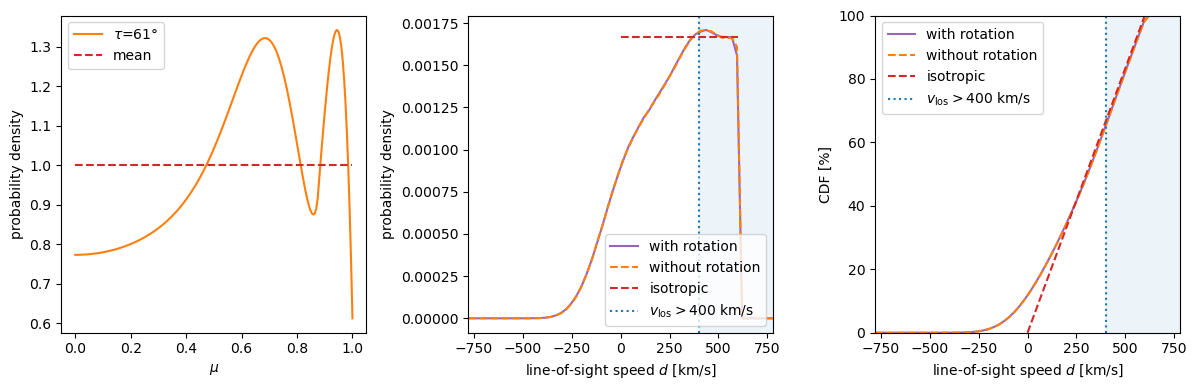

In [11]:
def plot_flare_cme_pdf_cdf_3x1_rotation(tau, dops, dens_by_label, v0, v_threshold=None,
                                         n_mu=200, name="dist"):
    mu = np.linspace(0, 1, int(n_mu))
    dops = np.asarray(dops, dtype=float)

    colors = {"with rotation": "tab:purple", "without rotation": "tab:orange"}
    linestyles = {"with rotation": "-", "without rotation": "--"}

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

    # visibility (near side + behind-the-limb margin) is already encoded in theta_max when
    # dens_by_label was computed, so no separate d >= 0 cut is applied here.
    d_pos = dops

    # (1) flare PDF in mu (same single tau as the non-rotating figure above)
    ax = axs[0]
    y = np.array([rho_mu(m, tau) for m in mu], dtype=float)
    ax.plot(mu, y / np.average(y), color="tab:orange", label=fr'$\tau$={int(round(tau*180/np.pi))}°')
    ax.plot(mu, np.ones_like(mu), "--", color="tab:red", label="mean")
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("probability density")
    ax.legend()

    # (2) CME PDF in line-of-sight speed d, normalised over the visible population's full support
    ax = axs[1]
    for label, dens_ in dens_by_label.items():
        d_pdf = dens_
        area = np.trapz(d_pdf, d_pos)
        ax.plot(d_pos, d_pdf / area, color=colors[label], linestyle=linestyles[label], label=label)
    d_iso = np.linspace(0, v0, 200)
    ax.plot(d_iso, np.full_like(d_iso, 1.0 / v0), "--", color="tab:red", label="isotropic")
    if v_threshold is not None:
        ax.axvspan(v_threshold, d_pos.max(), color="tab:blue", alpha=0.08)
        ax.axvline(v_threshold, color="tab:blue", linestyle=":", lw=1.5, label=fr"$v_{{\rm los}}>{v_threshold}$ km/s")
    ax.set_xlabel(r"line-of-sight speed $d$ [km/s]")
    ax.set_ylabel("probability density")
    ax.set_xlim(d_pos.min(), d_pos.max())
    ax.legend()

    # (3) CME CDF in d, percent
    ax = axs[2]
    for label, dens_ in dens_by_label.items():
        d_pdf = dens_
        cdf_ = cumulative_trapezoid(d_pdf, d_pos, initial=0)
        ax.plot(d_pos, cdf_ / cdf_[-1] * 100, color=colors[label], linestyle=linestyles[label], label=label)
    iso_cdf = np.clip((d_iso - 0) / v0 * 100, 0, 100)
    ax.plot(d_iso, iso_cdf, "--", color="tab:red", label="isotropic")
    if v_threshold is not None:
        ax.axvspan(v_threshold, d_pos.max(), color="tab:blue", alpha=0.08)
        ax.axvline(v_threshold, color="tab:blue", linestyle=":", lw=1.5, label=fr"$v_{{\rm los}}>{v_threshold}$ km/s")
    ax.set_xlabel(r"line-of-sight speed $d$ [km/s]")
    ax.set_ylabel("CDF [%]")
    ax.set_ylim(0, 100)
    ax.set_xlim(d_pos.min(), d_pos.max())
    ax.legend()

    plt.tight_layout()
    Path("Figures").mkdir(exist_ok=True)
    plt.savefig(f"Figures/{name}.pdf")
    return fig, axs


fig, axs = plot_flare_cme_pdf_cdf_3x1_rotation(
    tau=tau,
    dops=dops,
    dens_by_label={"with rotation": dens_rot_limb, "without rotation": dens_norot_limb},
    v0=v0,
    v_threshold=v_threshold,
    name="EK_Draconis_rotation_dist",
)
plt.show()

## Take-away

- Accounting for solar-like flares standing $h\approx0.01\,R_\star$ above the surface, we can see
  $\chi=\arccos\!\big(R/(R+h)\big)\approx8.1°$ past the geometric limb. Implementing this correctly
  means restricting the flare-position integral to $\theta\in[0,\pi/2+\chi]$ *inside* `mc_rho_dops`
  (not thresholding the resulting $d$-distribution afterwards, which cannot recover the same
  population — see the derivation above).
- With this fix, the model-predicted captured-CME fraction for EK Draconis is
  **34.8%** without rotation and **34.7%** with rotation — a **-0.11** percentage-point difference,
  still negligible, consistent with $\omega R\approx17$ km/s being only ~3% of $v_0=600$ km/s.
- This is *lower* than the earlier near-side-only estimate (~37.7-39.2%, no behind-the-limb
  contribution at all): including the marginally-visible limb-grazing population adds a small amount
  of low/negative-$d$ CMEs to the total (visible) population without meaningfully changing the count
  above the 400 km/s detection threshold, which dilutes the captured fraction slightly — the
  qualitative direction you'd expect from letting in more, low-speed, marginally-visible events.

